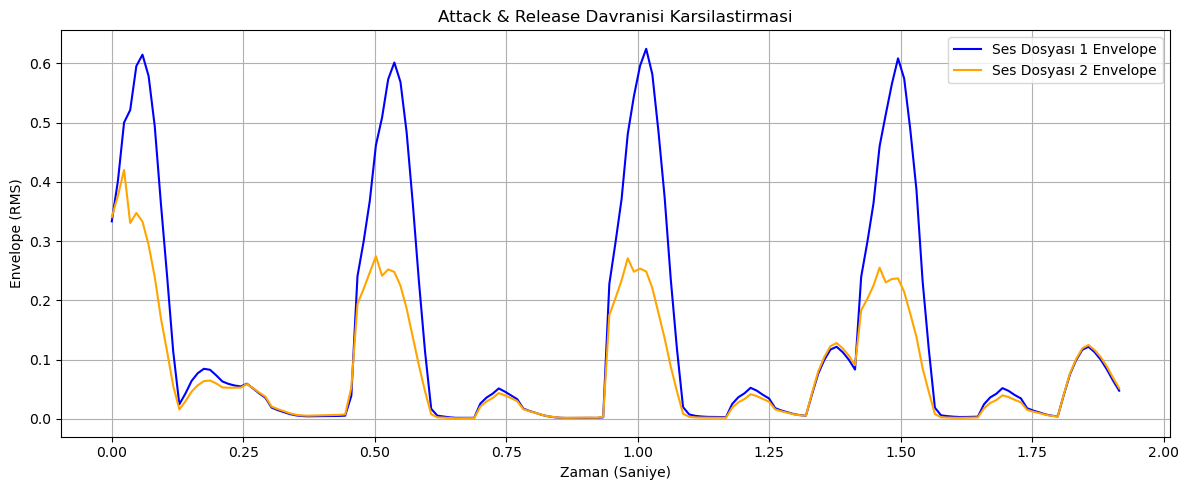

In [2]:
import matplotlib.pyplot as plt # Grafik çizimi için matplotlib kütüphanesi
import numpy as np # Sayısal hesaplamalar için numpy kütüphanesi
import librosa # Ses dosyası yükleme ve işleme
import librosa.display # Grafik gösterimi

# Ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/1.wav" # İlk karşılaştırılacak ses dosyasının yolu
file_2 = "/Users/nazimerensahin/Desktop/2.wav" # İkinci karşılaştırılacak ses dosyasının yolu

# Ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1" # Grafik etiketi için ilk dosya ismi
label_2 = "Ses Dosyası 2" # Grafik etiketi için ikinci dosya ismi

# Ses dosyalarını yükleme
wave_1, sr_1 = librosa.load(file_1, sr=None) # Birinci ses dosyasını yükleme
wave_2, sr_2 = librosa.load(file_2, sr=None) # İkinci ses dosyasını yükleme

# Parametreler
frame_size = 2048  # RMS hesaplama icin pencere boyutu
hop_length = 512  # Pencereler arası atlama adımı

# Zarf hesaplama fonksiyonu
def compute_envelope(signal, frame_size, hop_length):
    rms = librosa.feature.rms(y=signal, frame_length=frame_size, hop_length=hop_length)[0] # RMS hesaplama
    return rms # Hesaplanan zarf (RMS) değerlerini fonksiyonun çıktısı olarak döndürme

# Zarf (envelope) hesaplama
envelope_1 = compute_envelope(wave_1, frame_size, hop_length) # Birinci sesin zarfını hesapla
envelope_2 = compute_envelope(wave_2, frame_size, hop_length) # Ikinci sesin zarfını hesapla

# Zaman eksenini hesaplama
time_1 = np.linspace(0, len(envelope_1) * hop_length / sr_1, num=len(envelope_1)) # ilk ses zaman ekseni
time_2 = np.linspace(0, len(envelope_2) * hop_length / sr_2, num=len(envelope_2)) # İkinci ses zaman ekseni

# Grafik çizimi
plt.figure(figsize=(12, 5)) # Grafik boyutunu ayarlama
plt.plot(time_1, envelope_1, label=f"{label_1} Envelope", color='blue') # Birinci sesin zarfı
plt.plot(time_2, envelope_2, label=f"{label_2} Envelope", color='orange') # Ikinci sesin zarfı

# Başlık, etiketler ve diğer ayarlar
plt.title("Attack & Release Davranisi Karsilastirmasi") # Grafik başlığı
plt.xlabel("Zaman (Saniye)") # X ekseni etiketi
plt.ylabel("Envelope (RMS)") # Y ekseni etiketi
plt.legend(loc="upper right") # Lejant konumu
plt.grid(True) # Grafik ızgara çizgilerini oluşturma
plt.tight_layout() # Yerleşim optimizasyonu
plt.show() # Grafiği gösterme
